# CSI-Based People Counting: Classical ML Pipeline

Notebook ini membangun pipeline machine learning klasik (tanpa deep learning) untuk klasifikasi jumlah orang dalam ruangan berdasarkan Channel State Information (CSI).

Langkah utama:
- Load file `.mat` dari folder dataset
- Preprocessing: imputasi missing value, filtering Savitzky-Golay pada komponen real & imajiner
- Transformasi ke magnitude dan phase
- Windowing di domain waktu untuk menghasilkan banyak sampel
- Ekstraksi fitur statistik per window
- Training model Random Forest dan Gradient Boosting
- Evaluasi akurasi keseluruhan dan per kelas (confusion matrix)

# Import and Config

In [1]:
# Section 1: Set Up Environment and Imports

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

# Import dari utils package
from utils import config
from utils import (
    extract_label_from_filename,
    load_csi_matrix,
    collect_all_mat_files,
    impute_missing_per_subcarrier,
    apply_savgol_per_subcarrier,
    csi_to_mag_phase,
    window_indices,
    extract_features_from_window,
    make_xgboost_pipeline
)

# Akses konstanta dari config
DATASET_ROOT = config.DATASET_ROOT
PC_FOLDERS = config.PC_FOLDERS
WINDOW_SIZE = config.WINDOW_SIZE
WINDOW_STRIDE = config.WINDOW_STRIDE
RANDOM_STATE = config.RANDOM_STATE
TEST_SIZE = config.TEST_SIZE
VAL_SIZE = config.VAL_SIZE

print("Dataset root:", DATASET_ROOT)
print("PC folders:", PC_FOLDERS)
print("Window size:", WINDOW_SIZE)
print("Window stride:", WINDOW_STRIDE)


Dataset root: dataset
PC folders: ['PC-1a', 'PC-2a', 'PC-3a', 'PC-4a']
Window size: 200
Window stride: 100


In [3]:
# Contoh eksekusi: preprocessing & windowing satu file

example_file = os.path.join(DATASET_ROOT, "PC-3a", "PC3a_n04.mat")
if not os.path.exists(example_file):
    # Fallback: ambil file .mat pertama yang ada
    all_mats = collect_all_mat_files()
    if len(all_mats) == 0:
        raise FileNotFoundError("Tidak ada file .mat ditemukan untuk contoh.")
    example_file = all_mats[0]

print("Contoh file:", example_file)

# Tahap: load -> imputasi -> filter -> mag
csi_example = load_csi_matrix(example_file)
print("CSI shape (raw):", csi_example.shape)

csi_example = impute_missing_per_subcarrier(csi_example)
csi_example = apply_savgol_per_subcarrier(csi_example)
mag_example, _ = csi_to_mag_phase(csi_example)
print("Magnitude shape:", mag_example.shape)

# Windowing sederhana
n_time_ex = mag_example.shape[1]
example_windows = window_indices(n_time_ex, WINDOW_SIZE, WINDOW_STRIDE)
print("Jumlah window contoh:", len(example_windows))

if example_windows:
    start, end = example_windows[0]
    mag_win = mag_example[:, start:end]
    feats_example = extract_features_from_window(mag_win)
    print("Dimensi fitur 1 window:", feats_example.shape)


Contoh file: dataset\PC-3a\PC3a_n04.mat
CSI shape (raw): (242, 202268)
Magnitude shape: (242, 202268)
Jumlah window contoh: 2021
Dimensi fitur 1 window: (1210,)


In [2]:
# Section 3: Bangun full dataset dari semua file

all_files = collect_all_mat_files()
print(f"Ditemukan {len(all_files)} file .mat")


Ditemukan 39 file .mat


In [ ]:
# Ekstraksi fitur dari semua file

X_list = []
y_list = []

for path in all_files:
    print(f"Memproses {os.path.basename(path)} ...")
    label = extract_label_from_filename(path)
    csi = load_csi_matrix(path)
    csi = impute_missing_per_subcarrier(csi)
    csi = apply_savgol_per_subcarrier(csi)
    mag, _ = csi_to_mag_phase(csi)

    n_time = mag.shape[1]
    idx_list = window_indices(n_time, WINDOW_SIZE, WINDOW_STRIDE)

    if not idx_list:
        print("  (Lewat: tidak ada window valid)")
        continue

    for (start, end) in idx_list:
        mag_win = mag[:, start:end]
        feats = extract_features_from_window(mag_win)
        # Debug: pastikan dimensi fitur konsisten
        if len(feats) != 1210:
            print("Dimensi fitur tak terduga:", len(feats), os.path.basename(path))
        X_list.append(feats)
        y_list.append(label)

if not X_list:
    raise RuntimeError("Tidak ada sampel yang berhasil diekstrak dari file mana pun.")


Memproses PC1a_n00.mat ...
Memproses PC1a_n02.mat ...
Memproses PC1a_n03.mat ...
Memproses PC1a_n04.mat ...
Memproses PC1a_n05.mat ...
Memproses PC1a_n06.mat ...
Memproses PC1a_n07.mat ...
Memproses PC1a_n08.mat ...
Memproses PC1a_n09.mat ...
Memproses PC1a_n10.mat ...
Memproses PC2a_n02.mat ...
Memproses PC2a_n03.mat ...
Memproses PC2a_n04.mat ...
Memproses PC2a_n05.mat ...
Memproses PC2a_n06.mat ...
Memproses PC2a_n07.mat ...
Memproses PC2a_n08.mat ...
Memproses PC2a_n09.mat ...
Memproses PC2a_n10.mat ...
Memproses PC3a_n00.mat ...
Memproses PC3a_n02.mat ...
Memproses PC3a_n03.mat ...
Memproses PC3a_n04.mat ...
Memproses PC3a_n05.mat ...
Memproses PC3a_n06.mat ...
Memproses PC3a_n07.mat ...
Memproses PC3a_n08.mat ...
Memproses PC3a_n09.mat ...
Memproses PC3a_n10.mat ...
Memproses PC4a_n00.mat ...
Memproses PC4a_n02.mat ...
Memproses PC4a_n03.mat ...
Memproses PC4a_n04.mat ...
Memproses PC4a_n05.mat ...
Memproses PC4a_n06.mat ...
Memproses PC4a_n07.mat ...
Memproses PC4a_n08.mat ...
M

In [9]:
X_all = np.vstack(X_list)
y_all = np.array(y_list, dtype=int)

print("Total sampel:", X_all.shape[0])
print("Dimensi fitur per sampel:", X_all.shape[1])
print("Distribusi label:")
print(pd.Series(y_all).value_counts().sort_index())

print("\nShape X_all:", X_all.shape)
print("Shape y_all:", y_all.shape)

Total sampel: 72586
Dimensi fitur per sampel: 1210
Distribusi label:
0     6116
2     7820
3     6974
4     8041
5     7023
6     6875
7     7367
8     8138
9     6612
10    7620
Name: count, dtype: int64

Shape X_all: (72586, 1210)
Shape y_all: (72586,)


In [ ]:
# Section 3 (opsional): Simpan fitur terproses ke CSV

X_df = pd.DataFrame(X_all)
y_series = pd.Series(y_all, name="label")
df_out = X_df.copy()
df_out["label"] = y_series

# Tentukan folder dan nama file output
preprocessed_dir = os.path.join(DATASET_ROOT, "processed")
os.makedirs(preprocessed_dir, exist_ok=True)
output_csv_path = os.path.join(preprocessed_dir, "csi_windows_features.csv")

# Simpan ke CSV (tanpa index)
df_out.to_csv(output_csv_path, index=False)

print("Data fitur tersimpan ke:", output_csv_path)
print("Shape DataFrame tersimpan:", df_out.shape)


Data fitur tersimpan ke: dataset\processed\csi_windows_features.csv
Shape DataFrame tersimpan: (72586, 1211)


In [4]:
# Section 3 (opsional): Load fitur terproses dari CSV

preprocessed_dir = os.path.join(DATASET_ROOT, "processed")
input_csv_path = os.path.join(preprocessed_dir, "csi_windows_features.csv")

if not os.path.exists(input_csv_path):
    raise FileNotFoundError(f"File CSV tidak ditemukan: {input_csv_path}. Jalankan dulu cell ekspor fitur.")

df_loaded = pd.read_csv(input_csv_path)

# Asumsikan kolom terakhir adalah 'label' dan sisanya fitur
if "label" not in df_loaded.columns:
    raise ValueError("Kolom 'label' tidak ditemukan di file CSV.")

X_all = df_loaded.drop(columns=["label"]).values
y_all = df_loaded["label"].astype(int).values

print("Berhasil load fitur dari CSV:")
print("Total sampel:", X_all.shape[0])
print("Dimensi fitur per sampel:", X_all.shape[1])
print("Distribusi label:")
print(pd.Series(y_all).value_counts().sort_index())

print("\nShape X_all:", X_all.shape)
print("Shape y_all:", y_all.shape)


Berhasil load fitur dari CSV:
Total sampel: 72586
Dimensi fitur per sampel: 1210
Distribusi label:
0     6116
2     7820
3     6974
4     8041
5     7023
6     6875
7     7367
8     8138
9     6612
10    7620
Name: count, dtype: int64

Shape X_all: (72586, 1210)
Shape y_all: (72586,)


In [9]:
# Section 4: Split Dataset dan Label Encoding

# ================================
# Split train / val / test
# ================================

# Pertama, pisah test set dari total
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

# Dari sisa (X_temp), ambil val_size relatif terhadap total
remaining = 1.0 - TEST_SIZE
val_size_rel_to_temp = VAL_SIZE / remaining

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_size_rel_to_temp,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

# ================================
# Label Encoding (WAJIB untuk XGBoost)
# ================================

label_encoder = LabelEncoder()

# Fit HANYA di training label (best practice)
y_train = label_encoder.fit_transform(y_train)
y_val   = label_encoder.transform(y_val)
y_test  = label_encoder.transform(y_test)

# Simpan class names asli (untuk report & confusion matrix)
class_names = [str(c) for c in label_encoder.classes_]

print("Kelas asli:", class_names)
print("\nMapping label:")
for i, cls in enumerate(class_names):
    print(f"  {cls} -> {i}")


Train shape: (50810, 1210)
Val shape: (10888, 1210)
Test shape: (10888, 1210)
Kelas asli: ['0', '2', '3', '4', '5', '6', '7', '8', '9', '10']

Mapping label:
  0 -> 0
  2 -> 1
  3 -> 2
  4 -> 3
  5 -> 4
  6 -> 5
  7 -> 6
  8 -> 7
  9 -> 8
  10 -> 9


In [ ]:
# Section 5: Training dan Evaluasi XGBoost

xgb_model = make_xgboost_pipeline()

print("\n====================================")
print("Training XGBoost Classifier")
print("====================================")

xgb_model.fit(X_train, y_train)




Train accuracy: 0.9170
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4281
           2       0.96      0.97      0.97      5474
           3       0.90      0.94      0.92      4882
           4       0.93      0.90      0.92      5629
           5       0.92      0.88      0.90      4916
           6       0.94      0.87      0.90      4813
           7       0.92      0.89      0.90      5157
           8       0.90      0.91      0.90      5696
           9       0.91      0.88      0.89      4628
          10       0.83      0.94      0.88      5334

    accuracy                           0.92     50810
   macro avg       0.92      0.92      0.92     50810
weighted avg       0.92      0.92      0.92     50810



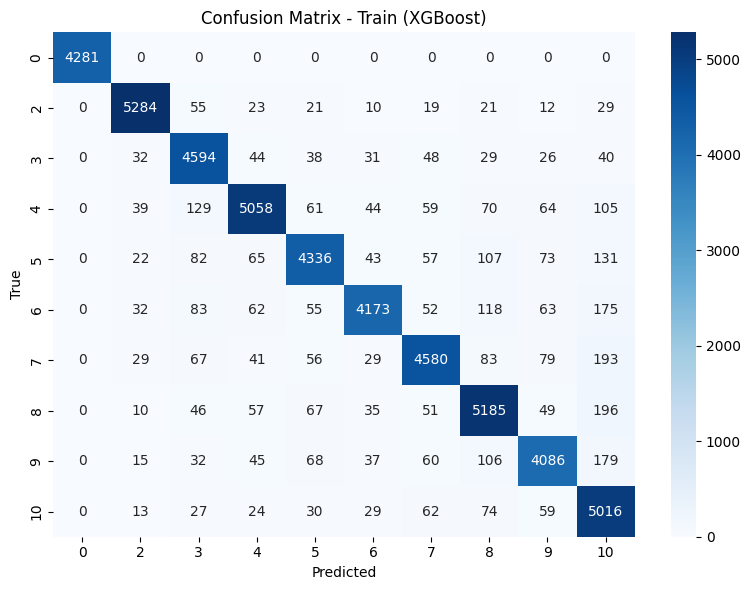


Validation accuracy: 0.5364
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       918
           2       0.76      0.79      0.77      1173
           3       0.53      0.57      0.55      1046
           4       0.50      0.52      0.51      1206
           5       0.47      0.42      0.44      1053
           6       0.41      0.29      0.34      1031
           7       0.43      0.41      0.42      1105
           8       0.41      0.47      0.44      1221
           9       0.42      0.33      0.37       992
          10       0.46      0.59      0.52      1143

    accuracy                           0.54     10888
   macro avg       0.54      0.54      0.54     10888
weighted avg       0.53      0.54      0.53     10888



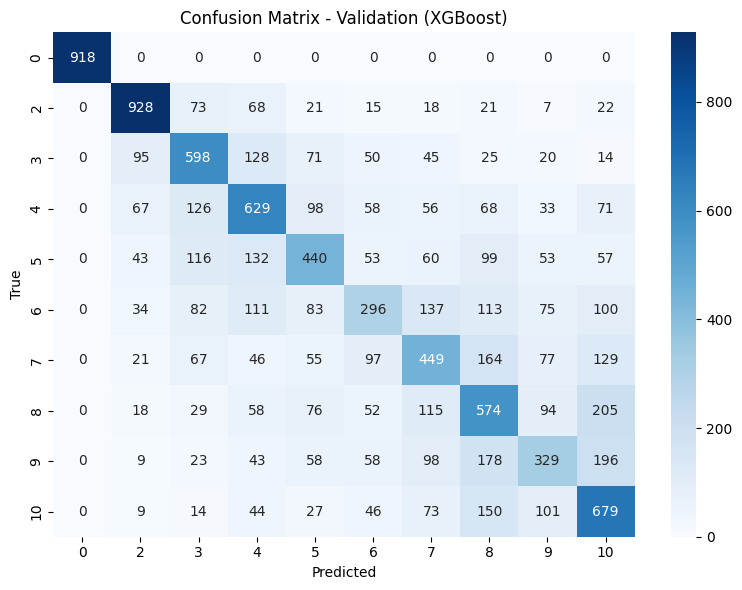


Test accuracy: 0.5434
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       917
           2       0.78      0.82      0.80      1173
           3       0.56      0.60      0.58      1046
           4       0.52      0.49      0.50      1206
           5       0.48      0.44      0.46      1054
           6       0.43      0.32      0.36      1031
           7       0.41      0.36      0.39      1105
           8       0.42      0.49      0.45      1221
           9       0.39      0.34      0.36       992
          10       0.47      0.62      0.53      1143

    accuracy                           0.54     10888
   macro avg       0.55      0.55      0.54     10888
weighted avg       0.54      0.54      0.54     10888



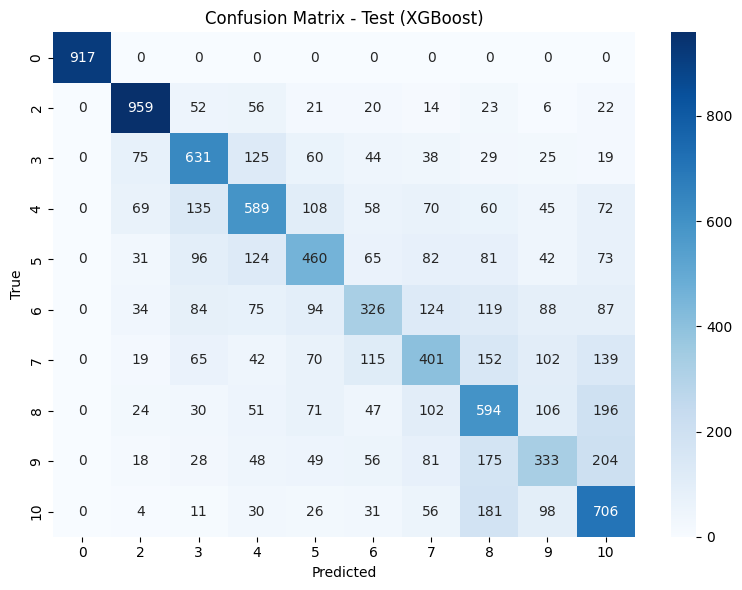

In [10]:

def xgb_report_split(name: str, X: np.ndarray, y_true: np.ndarray):
    y_pred = xgb_model.predict(X)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{name} accuracy: {acc:.4f}")
    print("Classification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,   # ✅ ini untuk NAMA
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)  # ✅ TANPA labels
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix - {name} (XGBoost)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


# Laporan di train, validation, dan test
xgb_report_split("Train", X_train, y_train)
xgb_report_split("Validation", X_val, y_val)
xgb_report_split("Test", X_test, y_test)